Importing the libraries

In [2]:
import pandas as pd
import numpy as np
import re
from gensim.models import KeyedVectors
# from nltk.corpus import stopwords
# from nltk.tokenize import word_tokenize

Defining variables here

In [3]:
TRAIN_DATA = 'train_data.csv'
TEST_DATA = 'test_data.csv'
TITLE_BRAND = 'title_brand.csv'
GOOGLE_VECTORS = 'GoogleNews-vectors-negative300.bin'

Loading the data

In [4]:
train_data = pd.read_csv(TRAIN_DATA)

train_data.head()

/tmp/ipykernel_44902/2754348164.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  train_data = pd.read_csv(TRAIN_DATA)


,overall,vote,verified,reviewTime,reviewerID,asin,style,reviewerName,reviewText,summary,unixReviewTime
0,2,NaN,False,2016-11-11,A2OSUEZJIN7BI,0511189877,NaN,Chris,I have an older URC-WR7 remote and thought thi...,Cannot Learn,1478822400
1,5,NaN,True,2016-06-06,A2NETQRG6JHIG7,0511189877,NaN,Qrysta White,First time I've EVER had a remote that needed ...,zero programming needed! Miracle!?,1465171200
2,4,NaN,True,2016-03-10,A12JHGROAX49G7,0511189877,NaN,Linwood,Got them and only 2 of them worked. company ca...,Works Good and programs easy.,1457568000
3,5,NaN,True,2016-01-14,A1KV65E2TMMG6F,0511189877,NaN,Dane Williams,I got tired of the remote being on the wrong s...,Same as TWC remote,1452729600
4,5,NaN,True,2016-10-20,A280POPEWI0NSA,0594459451,NaN,Kristina H.,After purchasing cheap cords from another webs...,Good Quality Cord,1476921600


In [5]:
test_data = pd.read_csv(TEST_DATA)

test_data.head()

,vote,verified,reviewTime,reviewerID,asin,style,reviewerName,reviewText,summary,unixReviewTime
0,NaN,True,2018-06-04,A20GGWE66JW9X2,B006Z394GM,{'Color:': ' FPS01-C'},Brian C Toner,The name and description of this device are mi...,The prize for most useless invention of all ti...,1528070400
1,NaN,True,2018-02-18,ARYJWXHEYHG9M,B005BE058W,"{'Size:': ' 1000W', 'Style:': ' G2'}",Snake,One of the molex connectors on the power suppl...,MELTED MOLEX CONNECTOR,1518912000
2,NaN,True,2018-01-20,A10LHZ7WFZ7HLL,B01DA0YCNC,NaN,Amazon Customer,Remote constantly disconnects/ Roku player fre...,Bricked on the regular,1516406400
3,NaN,True,2018-06-25,A11VN8EOHNLP72,B00FBJ4KYC,NaN,Jeremy Bray,I purchased this 4 year protection plan for a ...,DO NOT BUY!!!,1529884800
4,3.0,True,2016-08-17,A194Y8P8TVT7P9,B00P7G82TS,NaN,Mark,I bought one of these and have regretted it ev...,Nightmare - don't buy,1471392000


In [6]:
title_brand = pd.read_csv(TITLE_BRAND)

title_brand.head()

,asin,title,brand
0,0011300000,Genuine Geovision 1 Channel 3rd Party NVR IP S...,GeoVision
1,0043396828,"Books ""Handbook of Astronomical Image Processi...",33 Books Co.
2,0060009810,One Hot Summer,Visit Amazon's Carolina Garcia Aguilera Page
3,0060219602,Hurray for Hattie Rabbit: Story and pictures (...,Visit Amazon's Dick Gackenbach Page
4,0060786817,sex.lies.murder.fame.: A Novel,Visit Amazon's Lolita Files Page


# Section 1: Initial analysis of data

# Section 2: Level of satisfaction with a specific aspect

Let's find similar words to "warranty" and "guarantee"
We'll use pretrained word embeddings.

In [7]:
word_vectors = KeyedVectors.load_word2vec_format(GOOGLE_VECTORS, binary=True)
similar_warranty = [w for w, s in word_vectors.most_similar("warranty", topn=15)]
similar_guarantee = [w for w, s in word_vectors.most_similar("guarantee", topn=15)]
keywords = set(["warranty", "guarantee"] + similar_warranty + similar_guarantee)


In [8]:
print(keywords)

{'Lifetime_Warranty', 'warrantee', 'guarentee', 'assured', 'Warranties', 'powertrain_warranty', 'warrenty', 'warranties', 'Guaranteed', 'Extended_Warranty', 'assurance', 'insure', 'PMP_MP4_Players', 'Limited_Warranty', 'five-year/###_,###_mile', 'guarantee', 'warrantees', 'assurances', 'guaranteeing', 'warranty', 'limited_powertrain_warranty', 'Disclaimer_Past_performance', 'lifetime_warranty', 'assure', 'Guarantee', 'Warranty', 'corrosion_perforation', 'guarantees', 'ensure', 'guaranteed', 'gurantees', 'extended_warranties'}


Filtering reviews containing any of those words

In [9]:
pattern = r'\b(' + '|'.join(re.escape(k) for k in keywords) + r')\b'
train_data['mentions_warranty'] = train_data['reviewText'].str.lower().str.contains(pattern, regex=True)

/tmp/ipykernel_44902/995190863.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  train_data['mentions_warranty'] = train_data['reviewText'].str.lower().str.contains(pattern, regex=True)


In [10]:
train_data.head()

,overall,vote,verified,reviewTime,reviewerID,asin,style,reviewerName,reviewText,summary,unixReviewTime,mentions_warranty
0,2,NaN,False,2016-11-11,A2OSUEZJIN7BI,0511189877,NaN,Chris,I have an older URC-WR7 remote and thought thi...,Cannot Learn,1478822400,False
1,5,NaN,True,2016-06-06,A2NETQRG6JHIG7,0511189877,NaN,Qrysta White,First time I've EVER had a remote that needed ...,zero programming needed! Miracle!?,1465171200,False
2,4,NaN,True,2016-03-10,A12JHGROAX49G7,0511189877,NaN,Linwood,Got them and only 2 of them worked. company ca...,Works Good and programs easy.,1457568000,False
3,5,NaN,True,2016-01-14,A1KV65E2TMMG6F,0511189877,NaN,Dane Williams,I got tired of the remote being on the wrong s...,Same as TWC remote,1452729600,False
4,5,NaN,True,2016-10-20,A280POPEWI0NSA,0594459451,NaN,Kristina H.,After purchasing cheap cords from another webs...,Good Quality Cord,1476921600,False


Compute average rating per product

In [11]:
train_data_filtered = train_data[train_data['mentions_warranty']]
result = train_data_filtered.groupby('asin')['overall'].mean().reset_index()
result.rename(columns={'overall': 'mean_overall_warranty'}, inplace=True)


In [12]:
result['count_reviews'] = train_data_filtered.groupby('asin')['overall'].count().values

In [13]:
print(result)

             asin  mean_overall_warranty  count_reviews
0      6541654530                    1.0              1
1      9800466657                    5.0              1
2      B000001OM4                    4.0              1
3      B000001OM5                    5.0              1
4      B000001ON6                    5.0              1
...           ...                    ...            ...
12596  B01HIS5N3K                    4.0              2
12597  B01HIURQWE                    5.0              1
12598  B01HIWBU7Y                    5.0              1
12599  B01HIZEW1C                    5.0              1
12600  B01HJ8E11E                    5.0              1

[12601 rows x 3 columns]


In [14]:
# Create a binary sentiment label from the 'overall' rating:
# - ratings 4 and 5 => positive (1)
# - ratings 1 and 2 => negative (0)
# - rating 3 => neutral (we'll drop these for the binary analysis)
train_data_filtered['sentiment'] = train_data_filtered['overall'].apply(lambda r: 1 if r >= 4 else (0 if r <= 2 else np.nan))
# Drop neutral reviews (overall == 3) for the binary sentiment analysis
train_data_filtered = train_data_filtered.dropna(subset=['sentiment']).copy()
train_data_filtered['sentiment'] = train_data_filtered['sentiment'].astype(int)

# Robust parsing for 'vote' (helpful) field - some rows may be strings like '2 people found this helpful'
import re
def parse_vote(v):
    if pd.isna(v):
        return 0.0
    s = str(v)
    m = re.search(r'\d+', s)
    return float(m.group()) if m else 0.0

train_data_filtered['vote_num'] = train_data_filtered['vote'].apply(parse_vote)

# Normalize 'verified' to a boolean-like flag (handles True/False, 'Y'/'N', 'Yes'/'No', etc.)
train_data_filtered['verified_flag'] = train_data_filtered['verified'].astype(str).str.lower().isin(['true','y','yes','1'])

/tmp/ipykernel_44902/83307303.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data_filtered['sentiment'] = train_data_filtered['overall'].apply(lambda r: 1 if r >= 4 else (0 if r <= 2 else np.nan))


In [15]:
# Aggregate product-level metrics for items that mention warranty/guarantee
agg = train_data_filtered.groupby('asin').agg(
    mean_overall_warranty=('overall', 'mean'),
    count_reviews=('overall', 'count'),
    positive_reviews=('sentiment', lambda x: int((x==1).sum())),
    negative_reviews=('sentiment', lambda x: int((x==0).sum())),
    positivity_rate=('sentiment', lambda x: float(x.mean() if len(x) else np.nan)),
    mean_helpful_votes=('vote_num', 'mean'),
    percent_verified=('verified_flag', 'mean'),
    avg_review_length_words=('reviewText', lambda x: float(x.fillna('').str.split().str.len().mean())),
    avg_summary_length_words=('summary', lambda x: float(x.fillna('').str.split().str.len().mean())),
    first_review_time_unix=('unixReviewTime', 'min'),
    last_review_time_unix=('unixReviewTime', 'max')
)

agg = agg.reset_index()

# Some cleaning/formats for readability
agg['mean_helpful_votes'] = agg['mean_helpful_votes'].fillna(0).round(2)
agg['percent_verified'] = (agg['percent_verified'].fillna(0) * 100).round(1)
agg['positivity_rate'] = (agg['positivity_rate'].fillna(0) * 100).round(1)

# Save summary to CSV for later inspection
agg.to_csv('warranty_product_summary.csv', index=False)

print('Aggregated', len(agg), 'products mentioning warranty/guarantee. Saved to warranty_product_summary.csv')

Aggregated 11749 products mentioning warranty/guarantee. Saved to warranty_product_summary.csv


In [16]:
# Quick inspection: show top products by number of warranty-related reviews and worst/best mean rating
display_columns = ['asin','mean_overall_warranty','count_reviews','positive_reviews','negative_reviews','positivity_rate','mean_helpful_votes','percent_verified','avg_review_length_words']

print('Top 10 products by count of warranty-related reviews:')
display(agg.sort_values('count_reviews', ascending=False)[display_columns].head(10))

print('Top 10 products with lowest mean overall (warranty-related reviews):')
display(agg.sort_values('mean_overall_warranty', ascending=True)[display_columns].head(10))

print('Top 10 products with highest mean overall (warranty-related reviews):')
display(agg.sort_values('mean_overall_warranty', ascending=False)[display_columns].head(10))

# Show a couple example reviews for the single worst product (if exists) to inspect content
if len(agg):
    worst_asin = agg.sort_values('mean_overall_warranty', ascending=True).iloc[0]['asin']
    print('Example negative reviews mentioning warranty/guarantee for asin =', worst_asin)
    examples = train_data_filtered[train_data_filtered['asin'] == worst_asin].sort_values('unixReviewTime', ascending=False).head(5)
    display(examples[['overall','vote_num','verified_flag','reviewerName','summary','reviewText']])

Top 10 products by count of warranty-related reviews:


,asin,mean_overall_warranty,count_reviews,positive_reviews,negative_reviews,positivity_rate,mean_helpful_votes,percent_verified,avg_review_length_words
4732,B00LF10KTE,4.173913,46,37,9,80.4,1.59,82.6,140.586957
8699,B0163CHND0,1.577778,45,4,41,8.9,7.33,62.2,256.466667
4133,B00IVPU7AO,1.659091,44,6,38,13.6,21.00,90.9,137.136364
3063,B00DSUTX3O,4.159091,44,36,8,81.8,1.02,95.5,120.977273
2089,B008VQ8IKY,3.555556,36,23,13,63.9,2.86,91.7,137.833333
1227,B004LB5AZY,4.514286,35,32,3,91.4,1.49,51.4,244.857143
6051,B00S9SGNNS,2.968750,32,15,17,46.9,1.22,90.6,267.718750
7994,B013HSW4N2,3.032258,31,16,15,51.6,1.61,51.6,235.290323
5074,B00N1O1NQW,5.000000,29,29,0,100.0,6.79,75.9,87.724138
333,B000HPV3RW,3.964286,28,22,6,78.6,0.57,92.9,123.785714


Top 10 products with lowest mean overall (warranty-related reviews):


,asin,mean_overall_warranty,count_reviews,positive_reviews,negative_reviews,positivity_rate,mean_helpful_votes,percent_verified,avg_review_length_words
0,6541654530,1.0,1,0,1,0.0,0.00,100.0,104.0
2008,B00858I5OC,1.0,1,0,1,0.0,0.00,100.0,53.0
5908,B00RH69WRM,1.0,1,0,1,0.0,2.00,0.0,368.0
2010,B0085H18W4,1.0,3,0,3,0.0,5.67,66.7,358.0
5888,B00RCYEL7U,1.0,3,0,3,0.0,16.00,66.7,293.0
5885,B00RBQHC1G,1.0,1,0,1,0.0,0.00,100.0,42.0
5883,B00RBHGWRK,1.0,1,0,1,0.0,0.00,100.0,37.0
2017,B00877ZOYK,1.0,1,0,1,0.0,4.00,100.0,181.0
5878,B00RBG60ZK,1.0,1,0,1,0.0,2.00,100.0,201.0
5871,B00R98JVVU,1.0,1,0,1,0.0,0.00,100.0,122.0


Top 10 products with highest mean overall (warranty-related reviews):


,asin,mean_overall_warranty,count_reviews,positive_reviews,negative_reviews,positivity_rate,mean_helpful_votes,percent_verified,avg_review_length_words
11748,B01HJ8E11E,5.0,1,1,0,100.0,3.0,0.0,286.0
4659,B00L21Q5LY,5.0,1,1,0,100.0,17.0,100.0,80.0
9762,B01A5TNHWS,5.0,1,1,0,100.0,3.0,100.0,162.0
4655,B00L1O2PDY,5.0,1,1,0,100.0,6.0,100.0,1340.0
4654,B00L1LXOWS,5.0,1,1,0,100.0,3.0,0.0,244.0
4653,B00L1G6GCS,5.0,1,1,0,100.0,0.0,100.0,57.0
9763,B01A5UI5V0,5.0,2,2,0,100.0,0.0,0.0,128.5
9764,B01A60I4P6,5.0,2,2,0,100.0,27.0,0.0,3601.0
9767,B01A6B240Q,5.0,1,1,0,100.0,7.0,0.0,235.0
4645,B00L0IZZWY,5.0,1,1,0,100.0,0.0,100.0,55.0


Example negative reviews mentioning warranty/guarantee for asin = 6541654530


,overall,vote_num,verified_flag,reviewerName,summary,reviewText
734211,1,0.0,True,DannyPics,Lens doesn't work anymore,Originally the lens worked well. It hasn't bee...


In [17]:
# Post-processing: convert unix times to datetime and merge product titles/brands if available
import pandas as pd
merged = agg.copy()
# Convert unix timestamp columns (if present) to readable datetimes
for col in ['first_review_time_unix','last_review_time_unix']:
    if col in merged.columns:
        merged[col.replace('_unix','_date')] = pd.to_datetime(merged[col], unit='s', errors='coerce')

# Merge title/brand info if title_brand DataFrame is available and contains 'asin'
if 'title_brand' in globals():
    tb = title_brand.copy()
    if 'asin' in tb.columns:
        # pick common metadata columns if they exist
        meta_cols = [c for c in ['title','brand','product_title','product_name'] if c in tb.columns]
        use_cols = ['asin'] + meta_cols if meta_cols else ['asin']
        try:
            merged = merged.merge(tb[use_cols].drop_duplicates('asin'), on='asin', how='left')
        except Exception as e:
            print('Could not merge title_brand:', e)

# Save enhanced summary
merged.to_csv('warranty_product_summary_with_titles.csv', index=False)
print('Saved warranty_product_summary_with_titles.csv')
display(merged.head())

Saved warranty_product_summary_with_titles.csv


,asin,mean_overall_warranty,count_reviews,positive_reviews,negative_reviews,positivity_rate,mean_helpful_votes,percent_verified,avg_review_length_words,avg_summary_length_words,first_review_time_unix,last_review_time_unix,first_review_time_date,last_review_time_date,title,brand
0,6541654530,1.0,1,0,1,0.0,0.0,100.0,104.0,4.0,1475539200,1475539200,2016-10-04,2016-10-04,Canon EF 24-105mm f/4L IS USM Lens Bundle Inte...,Canon
1,9800466657,5.0,1,1,0,100.0,0.0,100.0,214.0,9.0,1492387200,1492387200,2017-04-17,2017-04-17,SanDisk EXTREME PRO 64GB (95MB/s) MicroSDXC wo...,SanDisk
2,B000001OM4,4.0,1,1,0,100.0,0.0,100.0,145.0,5.0,1470268800,1470268800,2016-08-04,2016-08-04,Maxell CD-330 CD-to-Cassette Audio Adapter (19...,Maxell
3,B000001OM5,5.0,1,1,0,100.0,0.0,100.0,118.0,13.0,1492473600,1492473600,2017-04-18,2017-04-18,Maxell Safe and Effective Feature CD Player an...,Maxell
4,B000001ON6,5.0,1,1,0,100.0,0.0,100.0,108.0,11.0,1500076800,1500076800,2017-07-15,2017-07-15,Maxell 290038 Vhs Cleaner Wet Premium,Maxell


## LSTM training plan and assumptions
We will train a binary sentiment classifier (positive vs negative) using an LSTM in PyTorch.
Assumptions:
- 
 will be used as the deep learning framework.
- Neutral reviews (overall == 3) were dropped earlier.
- We'll create a basic preprocessing/tokenization pipeline, build an embedding matrix from the loaded Word2Vec `word_vectors`, and fine-tune an LSTM.
- We'll produce many visualizations: class balance, review-length distribution, training/validation loss & accuracy, confusion matrix, ROC and PR curves, and sample misclassified reviews.
If you want TensorFlow instead, or prefer Hugging Face transformers, tell me and I can adapt.

In [18]:
# Imports, device and deterministic seeds
import random
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', DEVICE)

Using device: cuda


[nltk_data] Downloading package stopwords to /home/hazhir/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


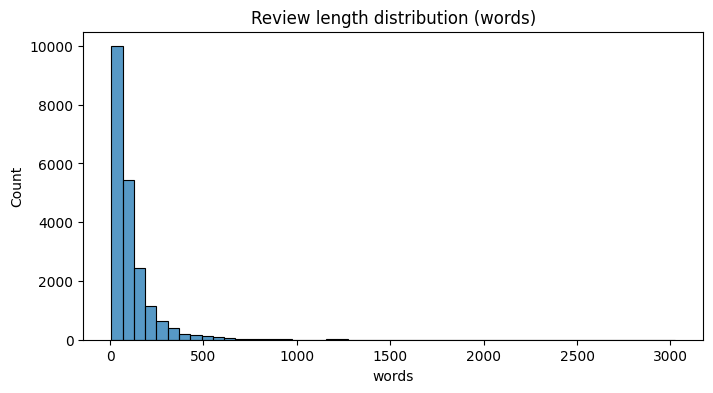

Class distribution:
sentiment
1    62.36%
0    37.64%
Name: proportion, dtype: object
Train/Val/Test sizes: 16681 2085 2086
Train class counts: sentiment
1    10403
0     6278
Name: count, dtype: int64
Train/Val/Test sizes: 16681 2085 2086
Train class counts (1..5):
sentiment
5    7757
1    4442
4    2646
2    1836
Name: count, dtype: int64
DataLoaders ready. Example batch:
torch.Size([64, 200]) torch.Size([64])


In [19]:
# Preprocessing: clean text, build vocabulary, sequences and DataLoaders
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
STOPWORDS = set(stopwords.words('english'))

def clean_text(text):
    if pd.isna(text):
        return ''
    s = str(text).lower()
    # remove urls
    s = re.sub(r'http\S+|www\.\S+', ' ', s)
    # remove html tags
    s = re.sub(r'<.*?>', ' ', s)
    # remove non-alphanumeric (keep spaces)
    s = re.sub(r'[^a-z0-9\s]', ' ', s)
    # collapse whitespace
    s = re.sub(r'\s+', ' ', s).strip()
    # remove stopwords (optional) and return
    tokens = [w for w in s.split() if w not in STOPWORDS]
    return ' '.join(tokens)

# create a cleaned text column (operate on train_data_filtered produced earlier)
train_data_filtered['text_clean'] = train_data_filtered['reviewText'].apply(clean_text)
train_data_filtered['text_len'] = train_data_filtered['text_clean'].str.split().apply(lambda x: len(x) if isinstance(x, list) else 0)

# plot review length distribution
plt.figure(figsize=(8,4))
sns.histplot(train_data_filtered['text_len'], bins=50, kde=False)
plt.title('Review length distribution (words)')
plt.xlabel('words')
plt.show()

# class balance
print('Class distribution:')
print(train_data_filtered['sentiment'].value_counts(normalize=True).map(lambda x: f'{x:.2%}'))

# prepare dataset for modeling: we'll use top vocab_size tokens
from collections import Counter
all_tokens = Counter()
for t in train_data_filtered['text_clean'].astype(str):
    all_tokens.update(t.split())

VOCAB_SIZE = 20000
most_common = [w for w,_ in all_tokens.most_common(VOCAB_SIZE-2)]  # reserve 0 pad,1 unk
word2idx = {w: i+2 for i,w in enumerate(most_common)}
word2idx['<PAD>'] = 0
word2idx['<UNK>'] = 1
idx2word = {i:w for w,i in word2idx.items()}

MAX_LEN = int(min(200, train_data_filtered['text_len'].quantile(0.95)))  # cap at 95th pct

def text_to_seq(text, maxlen=MAX_LEN):
    toks = text.split() if isinstance(text, str) else []
    seq = [word2idx.get(w,1) for w in toks][:maxlen]
    if len(seq) < maxlen:
        seq = seq + [0]*(maxlen-len(seq))
    return seq

train_data_filtered['seq'] = train_data_filtered['text_clean'].apply(lambda x: text_to_seq(x))

# create train/val/test splits stratified
train_df, temp_df = train_test_split(train_data_filtered, test_size=0.2, random_state=SEED, stratify=train_data_filtered['sentiment'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=SEED, stratify=temp_df['sentiment'])

class_counts = train_df['sentiment'].value_counts()
print('Train/Val/Test sizes:', len(train_df), len(val_df), len(test_df))
print('Train class counts:', class_counts)

train_data_filtered['sentiment'] = train_data_filtered['overall'].astype(int)  # 1..5

# Robust parsing for 'vote' (helpful) field - some rows may be strings like '2 people found this helpful'
import re
def parse_vote(v):
    if pd.isna(v):
        return 0.0
    s = str(v)
    m = re.search(r'\d+', s)
    return float(m.group()) if m else 0.0

train_data_filtered['vote_num'] = train_data_filtered['vote'].apply(parse_vote)

# Normalize 'verified' to a boolean-like flag
train_data_filtered['verified_flag'] = train_data_filtered['verified'].astype(str).str.lower().isin(['true','y','yes','1'])

# ensure text_clean and seq exist (if earlier cell created them, this is idempotent)
if 'text_clean' not in train_data_filtered.columns:
    train_data_filtered['text_clean'] = train_data_filtered['reviewText'].apply(clean_text)
if 'seq' not in train_data_filtered.columns:
    train_data_filtered['seq'] = train_data_filtered['text_clean'].apply(lambda x: text_to_seq(x))

# create train/val/test splits stratified by the 1..5 labels
from sklearn.model_selection import train_test_split
SEED = globals().get('SEED', 42)
train_df, temp_df = train_test_split(train_data_filtered, test_size=0.2, random_state=SEED, stratify=train_data_filtered['sentiment'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=SEED, stratify=temp_df['sentiment'])

class_counts = train_df['sentiment'].value_counts()
print('Train/Val/Test sizes:', len(train_df), len(val_df), len(test_df))
print('Train class counts (1..5):')
print(class_counts)

# Dataset and DataLoader: convert labels 1..5 -> 0..4 for CrossEntropyLoss
class ReviewDataset(Dataset):
    def __init__(self, df):
        self.seqs = df['seq'].tolist()
        # labels expected in df as 1..5 -> convert to 0..4
        self.labels = (df['sentiment'].astype(int) - 1).tolist()
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return torch.tensor(self.seqs[idx], dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)

BATCH_SIZE = 64
train_loader = DataLoader(ReviewDataset(train_df), batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader = DataLoader(ReviewDataset(val_df), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(ReviewDataset(test_df), batch_size=BATCH_SIZE, shuffle=False)

print('DataLoaders ready. Example batch:')
x,y = next(iter(train_loader))
print(x.shape, y.shape)

Prepared embedding matrix: vocab=20000, found in pre-trained=16260
Class weights (for classes 1..5): [0.9388226 2.271378  1.        1.5760581 0.5376112] present_labels: [1 2 4 5]
LSTMClassifier(
  (embedding): Embedding(20000, 300, padding_idx=0)
  (lstm): LSTM(300, 256, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.4, inplace=False)
  (fc1): Linear(in_features=1024, out_features=128, bias=True)
  (fc_out): Linear(in_features=128, out_features=5, bias=True)
  (relu): ReLU()
)
Epoch 1/10 - train_loss=1.2425 train_acc=0.4334 val_loss=1.0358 val_acc=0.6034
Saved best model
Epoch 2/10 - train_loss=1.0010 train_acc=0.5817 val_loss=1.0125 val_acc=0.6038
Saved best model
Epoch 3/10 - train_loss=0.8967 train_acc=0.6361 val_loss=0.9591 val_acc=0.6086
Saved best model
Epoch 4/10 - train_loss=0.8115 train_acc=0.6642 val_loss=0.9777 val_acc=0.6566
Epoch 5/10 - train_loss=0.7189 train_acc=0.7084 val_loss=0.9666 val_acc=0.5904
Epoch 6/10 - train_loss=0.5992 train_acc=0.7714 val_loss

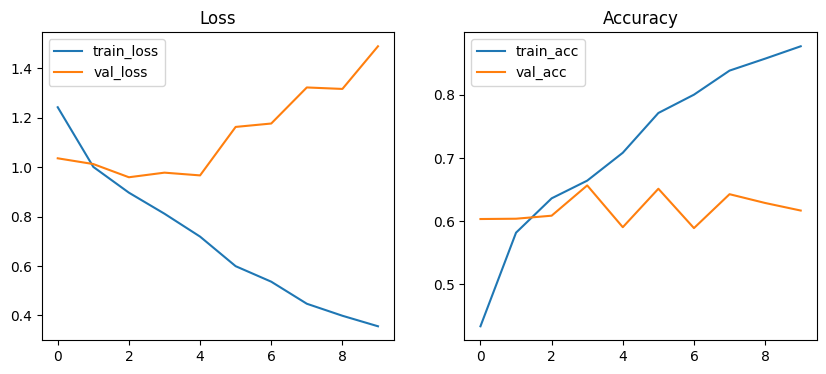

In [27]:
# Build embedding matrix from pre-trained word2vec (gensim KeyedVectors loaded earlier as word_vectors)
EMBEDDING_DIM = 300  # GoogleNews vectors are 300d
vocab_size = len(word2idx)
embedding_matrix = np.random.normal(scale=0.01, size=(vocab_size, EMBEDDING_DIM)).astype(np.float32)
found = 0
for w,i in word2idx.items():
    if w in ['<PAD>','<UNK>']:
        continue
    if w in word_vectors:
        embedding_matrix[i] = word_vectors[w]
        found += 1

print(f'Prepared embedding matrix: vocab={vocab_size}, found in pre-trained={found}')

# Compute class weights (robust: handles missing classes in the training split)
from sklearn.utils.class_weight import compute_class_weight
labels_np = train_df['sentiment'].astype(int).values  # expected 1..5
present_labels = np.unique(labels_np)
# compute weights for present labels
cw_partial = compute_class_weight(class_weight='balanced', classes=present_labels, y=labels_np)
# build full-length weight array for classes 1..5, default 1.0 for missing classes
cw_full = np.ones(5, dtype=np.float32)
for lbl, w in zip(present_labels, cw_partial):
    cw_full[int(lbl) - 1] = float(w)
class_weights = torch.tensor(cw_full, dtype=torch.float32).to(DEVICE)
print("Class weights (for classes 1..5):", cw_full, "present_labels:", present_labels)

# Define a simple LSTM classifier
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim=256, n_layers=1, bidirectional=True, dropout=0.4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))
        self.embedding.weight.requires_grad = True
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers=n_layers,
                            bidirectional=bidirectional, batch_first=True,
                            dropout=dropout if n_layers>1 else 0)
        feat_dim = hidden_dim * (2 if bidirectional else 1)
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(feat_dim * 2, 128)  # because we concat mean+max
        self.fc_out = nn.Linear(128, 5)
        self.relu = nn.ReLU()
    def forward(self, x):
        emb = self.embedding(x)
        out, _ = self.lstm(emb)
        # mean and max pooling
        mean_pool = out.mean(dim=1)
        max_pool, _ = out.max(dim=1)
        feats = torch.cat([mean_pool, max_pool], dim=1)
        x = self.dropout(feats)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc_out(x)

model = LSTMClassifier(vocab_size=vocab_size, embedding_dim=EMBEDDING_DIM).to(DEVICE)
print(model)

# Use weighted loss to address imbalance -- weights correspond to classes 1..5 (CrossEntropy expects 0..C-1 targets)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=1)
NUM_EPOCHS = 10

# Training loop with metrics recording
history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
best_val_loss = float('inf')
best_model_path = 'best_lstm.pt'

def evaluate(loader, model, device):
    model.eval()
    ys, ys_pred = [], []
    running_loss = 0.0
    with torch.no_grad():
        for xb,yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            running_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1).cpu().numpy()
            ys.extend(yb.cpu().numpy().tolist())
            ys_pred.extend(preds.tolist())
    avg_loss = running_loss / len(loader.dataset)
    acc = (np.array(ys) == np.array(ys_pred)).mean()
    return avg_loss, acc, ys, ys_pred

for epoch in range(1, NUM_EPOCHS+1):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for xb,yb in train_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += xb.size(0)
    train_loss = running_loss / len(train_loader.dataset)
    train_acc = correct / total
    val_loss, val_acc, _, _ = evaluate(val_loader, model, DEVICE)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    print(f'Epoch {epoch}/{NUM_EPOCHS} - train_loss={train_loss:.4f} train_acc={train_acc:.4f} val_loss={val_loss:.4f} val_acc={val_acc:.4f}')
    # scheduler step (ReduceLROnPlateau expects a metric)
    scheduler.step(val_loss)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_model_path)
        print('Saved best model')

# Plot training curves
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history['train_loss'], label='train_loss')
plt.plot(history['val_loss'], label='val_loss')
plt.legend()
plt.title('Loss')
plt.subplot(1,2,2)
plt.plot(history['train_acc'], label='train_acc')
plt.plot(history['val_acc'], label='val_acc')
plt.legend()
plt.title('Accuracy')
plt.show()

Test loss=0.3308 test_acc=0.8691
Classification report:
              precision    recall  f1-score   support

           0     0.8012    0.8675    0.8330       785
           1     0.9159    0.8701    0.8924      1301

    accuracy                         0.8691      2086
   macro avg     0.8585    0.8688    0.8627      2086
weighted avg     0.8727    0.8691    0.8701      2086



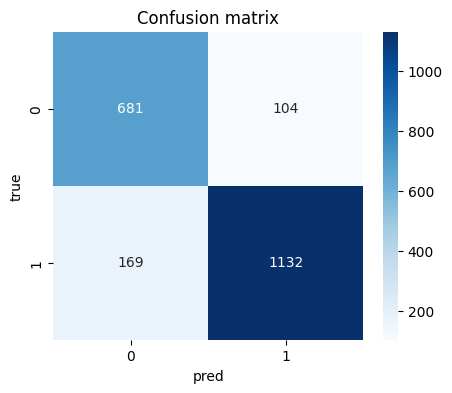

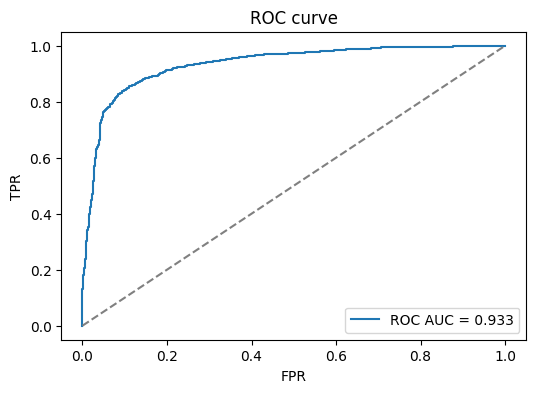

Example misclassified reviews:


,overall,sentiment,pred,vote_num,verified_flag,reviewerName,summary,reviewText
253,1,0,1,0.0,True,Brenda L.Welch,Observe your warranty before you buy any prote...,If you buy something NEW common sense is you g...
833,4,1,0,0.0,True,Jauffrey,You pay a pretty penny for the privilege,This product is one of few that is actually mo...
555,5,1,0,2.0,True,R. Wagner,This is a good cable. Going cheaper is false ...,This is a good cable. Cables are difficult to...
1594,1,0,1,0.0,True,OSPINA01,Don't ever buy,Read my update!\nThis is a lot of bang for the...
1596,2,0,1,2.0,False,feinuklein,Mother board problems,I purchased this TV in Feb 2015 and now it no ...
1070,4,1,0,0.0,True,J. Hermiller,"Nice, slim monitor but when I really get to ...","Nice, slim monitor but when I really get to ty..."
1580,4,1,0,3.0,True,Michael Jennings,Good drives. Insufficient management by Seagat...,Good: We have been delivering Seagate hard dri...
311,2,0,1,6.0,True,E. L. Green,"Big, sharp, and nice feature set -- but poor q...",UPDATE: Immediately after the warranty expired...


In [21]:
# Load best model and evaluate on test set
model.load_state_dict(torch.load('best_lstm.pt'))
test_loss, test_acc, ys_true, ys_pred = evaluate(test_loader, model, DEVICE)
print(f'Test loss={test_loss:.4f} test_acc={test_acc:.4f}')

# Classification report and confusion matrix
print('Classification report:')
print(classification_report(ys_true, ys_pred, digits=4))
cm = confusion_matrix(ys_true, ys_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('pred')
plt.ylabel('true')
plt.title('Confusion matrix')
plt.show()

# ROC curve (need probabilities) - get softmax scores on test set
def predict_probs(loader, model, device):
    model.eval()
    probs = []
    ys = []
    with torch.no_grad():
        for xb,yb in loader:
            xb = xb.to(device)
            logits = model(xb)
            p = torch.softmax(logits, dim=1)[:,1].cpu().numpy()
            probs.extend(p.tolist())
            ys.extend(yb.numpy().tolist())
    return np.array(ys), np.array(probs)

ys, probs = predict_probs(test_loader, model, DEVICE)
fpr, tpr, _ = roc_curve(ys, probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC curve')
plt.legend()
plt.show()

# Show some misclassified examples
test_df = test_df.reset_index(drop=True)
preds = []
# map sequences back to predictions by iterating with batch size
for xb,yb in test_loader:
    xb = xb.to(DEVICE)
    logits = model(xb)
    p = logits.argmax(dim=1).cpu().numpy().tolist()
    preds.extend(p)
test_df['pred'] = preds[:len(test_df)]
mis = test_df[test_df['pred'] != test_df['sentiment']].sample(min(8, len(test_df[test_df['pred'] != test_df['sentiment']])), random_state=SEED)
print('Example misclassified reviews:')
display(mis[['overall','sentiment','pred','vote_num','verified_flag','reviewerName','summary','reviewText']])

## Interactive evaluation and diagnostics
Use the cells below to load a CSV of labeled reviews (must include `reviewText` and `sentiment` columns where sentiment is 0/1) or pass a DataFrame in memory. The notebook will preprocess texts, run the saved LSTM (`best_lstm.pt`) and produce detailed diagnostics explaining what the model got wrong and potential reasons.

In [21]:
# Helper functions for evaluation on external data
def prepare_external_df(df):
    # expects df with 'reviewText' and 'sentiment' (0/1)
    d = df.copy()
    d['text_clean'] = d['reviewText'].astype(str).apply(clean_text)
    d['seq'] = d['text_clean'].apply(lambda x: text_to_seq(x))
    d['text_len'] = d['text_clean'].str.split().apply(lambda x: len(x) if isinstance(x, list) else 0)
    return d

def predict_on_df(d, model, batch_size=64):
    ds = ReviewDataset(d)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
    probs = []
    preds = []
    with torch.no_grad():
        for xb,yb in loader:
            xb = xb.to(DEVICE)
            logits = model(xb)
            p = torch.softmax(logits, dim=1)[:,1].cpu().numpy()
            pr = logits.argmax(dim=1).cpu().numpy()
            probs.extend(p.tolist())
            preds.extend(pr.tolist())
    d = d.reset_index(drop=True).copy()
    d['pred_prob'] = probs[:len(d)]
    d['pred'] = preds[:len(d)]
    return d

# Example usage: load a CSV with labeled reviews (user can change filename)
EXTERNAL_CSV = 'external_reviews.csv'  # change to your file if needed
import os
if os.path.exists(EXTERNAL_CSV):
    ext_df = pd.read_csv(EXTERNAL_CSV)
    if 'reviewText' in ext_df.columns and 'sentiment' in ext_df.columns:
        print('Preparing external data...')
        ext_ready = prepare_external_df(ext_df)
        model.load_state_dict(torch.load('best_lstm.pt'))
        model.to(DEVICE)
        ext_pred = predict_on_df(ext_ready, model)
        print('Done.')
    else:
        print('external CSV found but missing required columns: reviewText and sentiment')
else:
    print('No external CSV found at', EXTERNAL_CSV, '. To use this feature, place a CSV with columns reviewText and sentiment in the notebook folder or set EXTERNAL_CSV to the path.')

No external CSV found at external_reviews.csv . To use this feature, place a CSV with columns reviewText and sentiment in the notebook folder or set EXTERNAL_CSV to the path.


In [22]:
# If ext_pred exists, compute diagnostics
if 'ext_pred' in globals():
    from sklearn.calibration import calibration_curve
    y_true = ext_pred['sentiment'].values
    y_prob = ext_pred['pred_prob'].values
    y_pred = ext_pred['pred'].values
    print('Accuracy:', (y_true == y_pred).mean())
    print(classification_report(y_true, y_pred, digits=4))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion matrix (external)')
    plt.show()

    # Calibration curve
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10)
    plt.figure(figsize=(6,4))
    plt.plot(prob_pred, prob_true, marker='o')
    plt.plot([0,1],[0,1],'--', color='gray')
    plt.xlabel('Mean predicted probability')
    plt.ylabel('Fraction of positives')
    plt.title('Calibration curve')
    plt.show()

    # ROC and PR
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.3f}')
    plt.plot([0,1],[0,1],'--', color='gray')
    plt.title('ROC')
    plt.legend()
    plt.subplot(1,2,2)
    plt.plot(recall, precision)
    plt.title('Precision-Recall')
    plt.show()

    # Error analysis: distribution of predicted probabilities for correct vs incorrect
    ext_pred['correct'] = (ext_pred['pred'] == ext_pred['sentiment'])
    plt.figure(figsize=(8,4))
    sns.kdeplot(ext_pred[ext_pred['correct']==True]['pred_prob'], label='correct')
    sns.kdeplot(ext_pred[ext_pred['correct']==False]['pred_prob'], label='incorrect')
    plt.title('Predicted probability distribution: correct vs incorrect')
    plt.legend()
    plt.show()

    # Relationship between review length and correctness
    plt.figure(figsize=(8,4))
    sns.boxplot(x='sentiment', y='text_len', hue='correct', data=ext_pred)
    plt.title('Review length (words) by true sentiment and correctness')
    plt.show()

    # Show top confident wrong predictions (model very sure but wrong)
    wrong = ext_pred[ext_pred['correct']==False].copy()
    wrong['conf'] = np.abs(wrong['pred_prob'] - 0.5) * 2  # distance from 0.5
    top_wrong = wrong.sort_values('conf', ascending=False).head(10)
    print('Top confident wrong predictions:')
    display(top_wrong[['reviewText','sentiment','pred','pred_prob','text_len','summary']])

    # Save diagnostics
    ext_pred.to_csv('external_predictions_with_diagnostics.csv', index=False)
    print('Saved external_predictions_with_diagnostics.csv')
else:
    print('Run the previous cell to load an external CSV as EXTERNAL_CSV in the notebook folder.')

Run the previous cell to load an external CSV as EXTERNAL_CSV in the notebook folder.


In [23]:
# ...existing code...
# { changed code - replace predict_on_df and predict_probs to handle multiclass and update submission code }
def predict_on_df(d, model, batch_size=64):
    # returns DataFrame with 'pred' (0..4), 'pred_prob' (max probability), and 'pred_probas' (list of class probs)
    ds = ReviewDataset(d)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
    preds = []
    pred_probs = []
    pred_probas = []
    model.eval()
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            logits = model(xb)
            probs_batch = torch.softmax(logits, dim=1).cpu().numpy()
            pred_batch = probs_batch.argmax(axis=1)
            max_prob = probs_batch.max(axis=1)
            preds.extend(pred_batch.tolist())
            pred_probs.extend(max_prob.tolist())
            pred_probas.extend(probs_batch.tolist())
    d = d.reset_index(drop=True).copy()
    d['pred'] = preds[:len(d)]
    d['pred_prob'] = pred_probs[:len(d)]
    d['pred_probas'] = pred_probas[:len(d)]
    return d

def predict_probs(loader, model, device):
    # return true labels (0..4) and max-prob per sample (useful for simple ROC/calibration)
    model.eval()
    max_probs = []
    ys = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = model(xb)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            max_probs.extend(probs.max(axis=1).tolist())
            ys.extend(yb.cpu().numpy().tolist())
    return np.array(ys), np.array(max_probs)

# --- Submission generation: map predicted class indices (0..4) back to 1..5 ---
from sklearn.metrics import f1_score
class TestDataset(Dataset):
    def __init__(self, seqs):
        self.seqs = seqs
    def __len__(self):
        return len(self.seqs)
    def __getitem__(self, idx):
        return torch.tensor(self.seqs[idx], dtype=torch.long)

if 'test_data' in globals():
    td = test_data.copy()
    td['text_clean'] = td['reviewText'].astype(str).apply(clean_text)
    td['seq'] = td['text_clean'].apply(lambda x: text_to_seq(x))
    test_seqs = td['seq'].tolist()
    test_ds = TestDataset(test_seqs)
    test_loader_sub = DataLoader(test_ds, batch_size=64, shuffle=False)

    # load best model (expects final layer size = 5)
    model.load_state_dict(torch.load('best_lstm.pt', map_location=DEVICE))
    model.to(DEVICE)
    model.eval()

    preds = []
    probs = []
    with torch.no_grad():
        for xb in test_loader_sub:
            xb = xb.to(DEVICE)
            logits = model(xb)
            probs_batch = torch.softmax(logits, dim=1).cpu().numpy()
            pred_batch = probs_batch.argmax(axis=1)
            max_prob = probs_batch.max(axis=1)
            probs.extend(max_prob.tolist())
            preds.extend(pred_batch.tolist())

    # map 0..4 -> 1..5 for submission
    submission = pd.DataFrame({'predicted': [int(p) + 1 for p in preds]})
    submission.to_csv('q2_submission.csv', index=False)
    print("Saved q2_submission.csv with", len(submission), "rows. First rows:")
    print(submission.head())

    # If test_data includes ground-truth ratings, compute local micro F1 (1..5)
    if 'sentiment' in td.columns:
        y_true = td['sentiment'].astype(int).values[:len(preds)]  # 1..5
        y_pred_1to5 = np.array([p + 1 for p in preds], dtype=int)
        micro_f1 = f1_score(y_true, y_pred_1to5, average='micro')
        print(f"Local micro F1 on provided test_data.sentiment = {micro_f1:.4f}")
    elif 'overall' in td.columns:
        y_true = td['overall'].astype(int).values
        if len(y_true) == len(preds):
            y_pred_1to5 = np.array([p + 1 for p in preds], dtype=int)
            micro_f1 = f1_score(y_true, y_pred_1to5, average='micro')
            print(f"Local micro F1 (from overall) = {micro_f1:.4f}")
        else:
            print("Cannot compute micro F1: number of labeled rows != number of predictions.")
else:
    print("test_data not found in notebook globals. Load test_data.csv earlier and re-run this cell.")
# ...existing code...

Saved q2_submission.csv with 20000 rows. First rows:
   predicted
0          1
1          1
2          1
3          1
4          1
